In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Create sample data
np.random.seed(42)
n_students = 200
data = {
'student_id': range(1000, 1000 + n_students),
'study_hours': np.random.uniform(0, 20, n_students),
'sleep_hours': np.random.uniform(4, 10, n_students),
'prev_exam_score': np.random.uniform(50, 100, n_students),
'attendance': np.random.uniform(60, 100, n_students),
'gender': np.random.choice(['M', 'F'], n_students),
'major': np.random.choice(['CS', 'ENG', 'BUS', 'SCI'], n_students)
}
# Create target variable (exam score) with some relationship to features
data['final_score'] = (
30 +
2.5 * data['study_hours'] +
1.2 * data['prev_exam_score'] * 0.3 +
0.8 * data['attendance'] +
np.random.randn(n_students) * 5 # Add noise
)
# Add some missing values to make it realistic
df = pd.DataFrame(data)
missing_idx = np.random.choice(n_students, 10, replace=False)
df.loc[missing_idx, 'study_hours'] = np.nan
df.loc[missing_idx[:5], 'sleep_hours'] = np.nan
# Save to CSV
df.to_csv('student_performance.csv', index=False)
print("Dataset created and saved to 'student_performance.csv'")

Dataset created and saved to 'student_performance.csv'


In [2]:
# Basic info
print("Dataset Info:")
df.info()
print("\nSummary Statistics:")
df.describe()
print("\nMissing Values:")
df.isnull().sum()
print("\nData Types:")
df.dtypes


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       200 non-null    int64  
 1   study_hours      190 non-null    float64
 2   sleep_hours      195 non-null    float64
 3   prev_exam_score  200 non-null    float64
 4   attendance       200 non-null    float64
 5   gender           200 non-null    str    
 6   major            200 non-null    str    
 7   final_score      200 non-null    float64
dtypes: float64(5), int64(1), str(2)
memory usage: 12.6 KB

Summary Statistics:

Missing Values:

Data Types:


student_id           int64
study_hours        float64
sleep_hours        float64
prev_exam_score    float64
attendance         float64
gender                 str
major                  str
final_score        float64
dtype: object

In [3]:
# Create a clean copy
df_clean = df.copy()
# Fill missing study_hours with median
median_study = df_clean['study_hours'].median()
df_clean['study_hours'] = df_clean['study_hours'].fillna(median_study)
# Fill missing sleep_hours with mean
mean_sleep = df_clean['sleep_hours'].mean()
df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(mean_sleep)
# Verify no missing values remain
print(f"Missing values after cleaning:\n{df_clean.isnull().sum()}")

Missing values after cleaning:
student_id         0
study_hours        0
sleep_hours        0
prev_exam_score    0
attendance         0
gender             0
major              0
final_score        0
dtype: int64


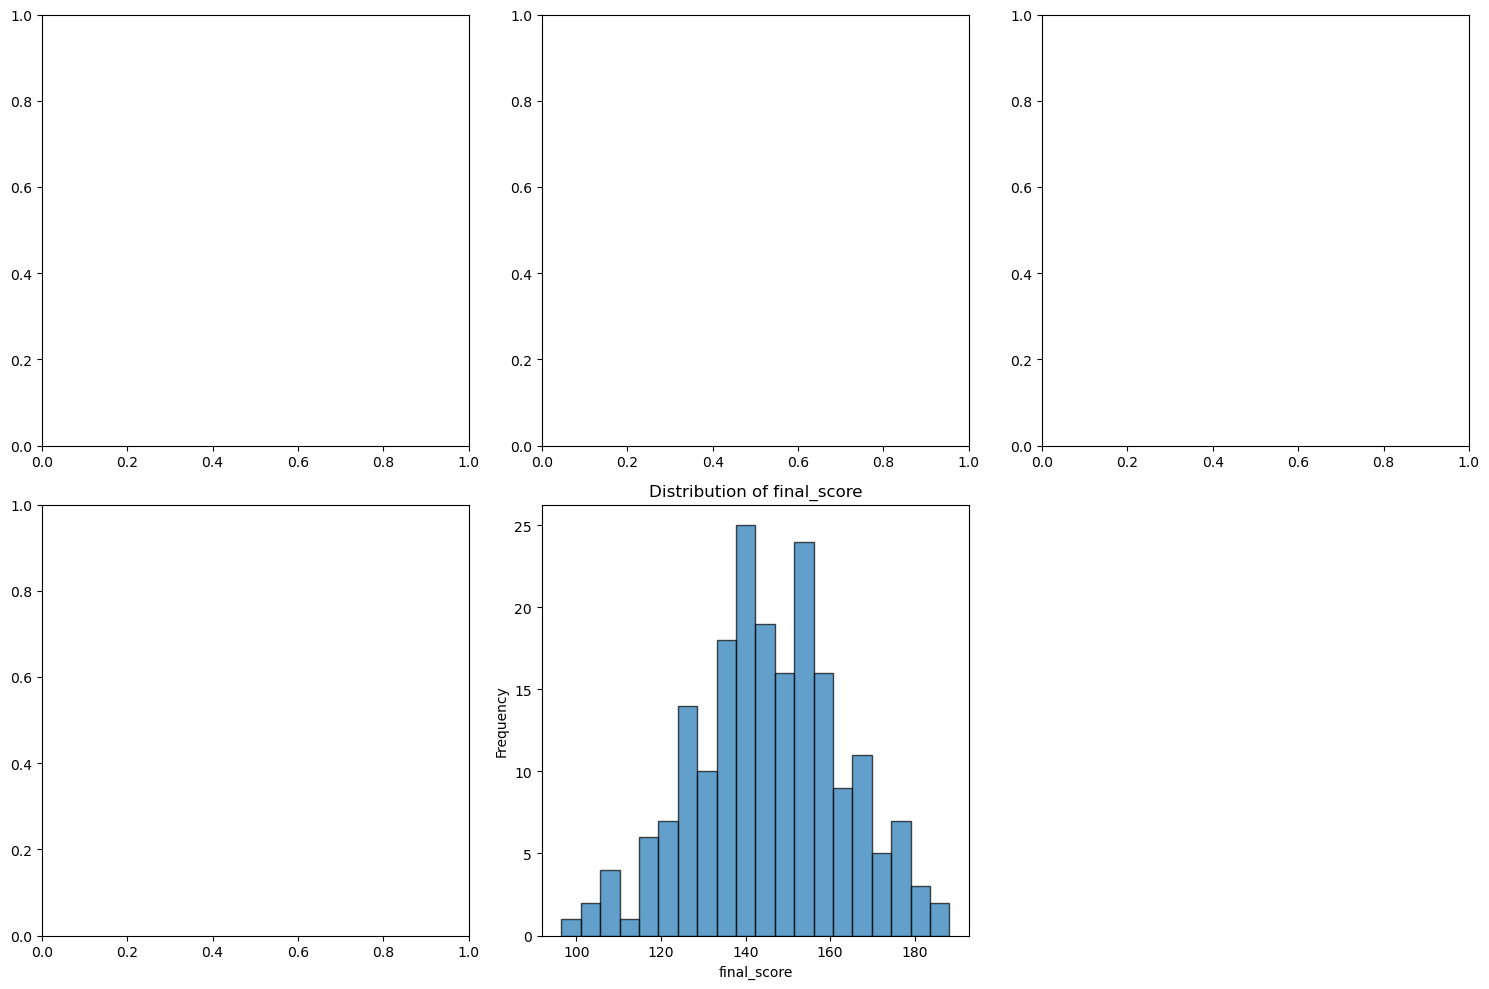

In [7]:
# Create histograms for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numerical_cols = ['study_hours', 'sleep_hours', 'prev_exam_score',
'attendance', 'final_score']
for i, col in enumerate(numerical_cols):
    row = i // 3
    col_idx = i % 3
axes[row, col_idx].hist(df_clean[col], bins=20, edgecolor='black', alpha=0.7)
axes[row, col_idx].set_title(f'Distribution of {col}')
axes[row, col_idx].set_xlabel(col)
axes[row, col_idx].set_ylabel('Frequency')
# Hide empty subplot
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

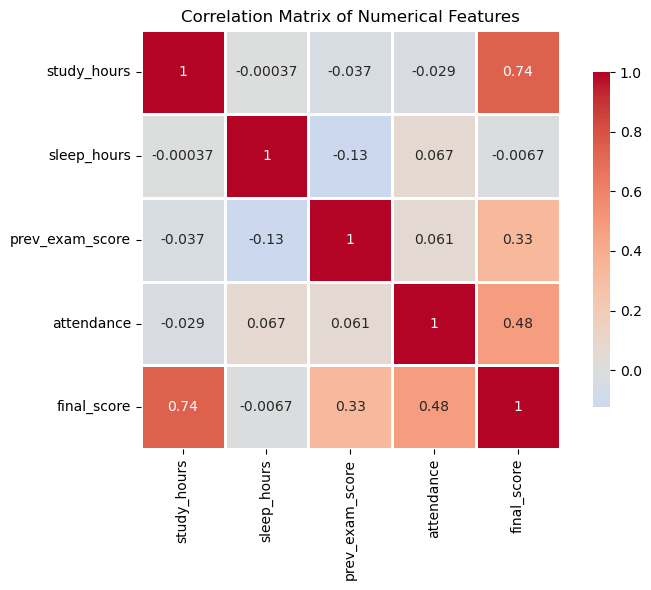

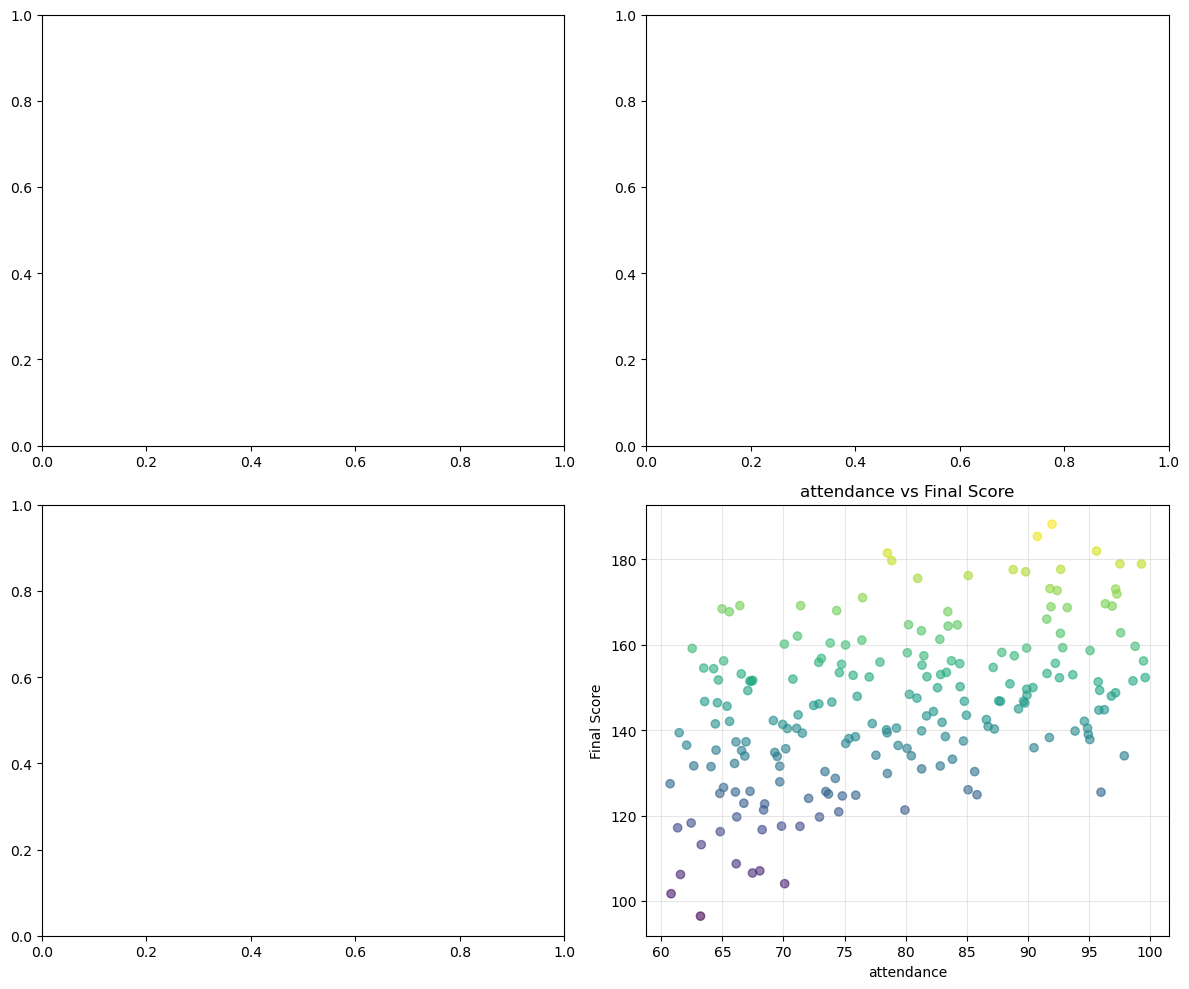

In [8]:
# Correlation matrix
correlation_matrix = df_clean[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()
# Scatter plots with final_score
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['study_hours', 'sleep_hours', 'prev_exam_score', 'attendance']
for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
axes[row, col].scatter(df_clean[feature], df_clean['final_score'],
alpha=0.6, c=df_clean['final_score'], cmap='viridis')
axes[row, col].set_xlabel(feature)
axes[row, col].set_ylabel('Final Score')
axes[row, col].set_title(f'{feature} vs Final Score')
axes[row, col].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

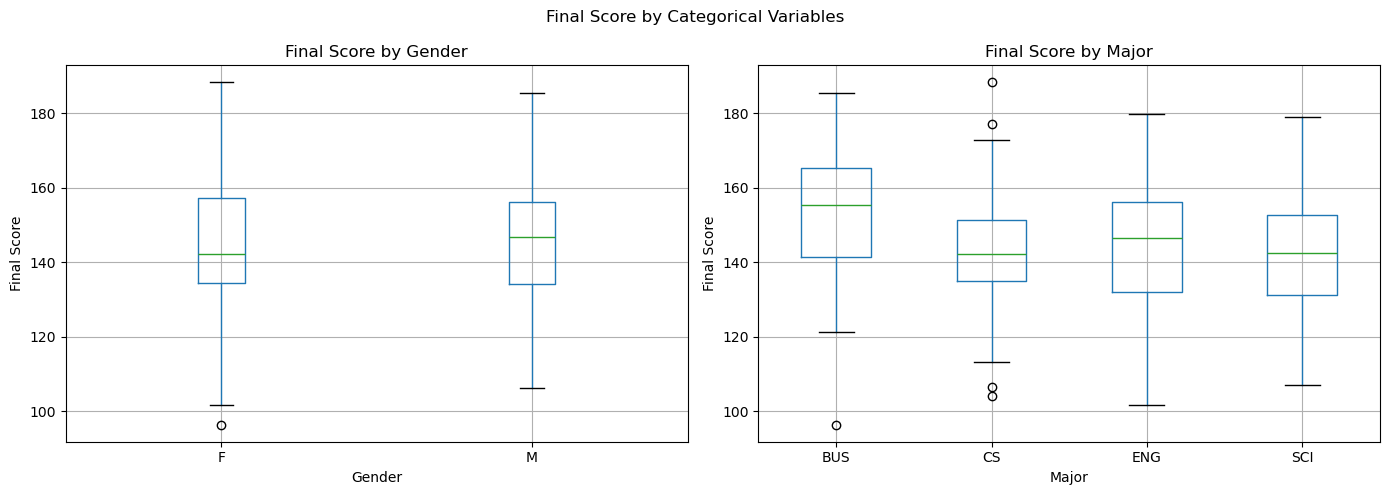

In [9]:
# Box plots by categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# By gender
df_clean.boxplot(column='final_score', by='gender', ax=axes[0])
axes[0].set_title('Final Score by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Final Score')
# By major
df_clean.boxplot(column='final_score', by='major', ax=axes[1])
axes[1].set_title('Final Score by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Final Score')
plt.suptitle('Final Score by Categorical Variables') # Remove automatic suptitle
plt.tight_layout()
plt.show()